# <b><font color='lightcoral'>Практикум Метрики, переобучение, недообучение</font></b>

In [24]:
# Импорт библиотек
from sklearn.datasets import fetch_california_housing, load_breast_cancer, load_wine, load_digits, load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeClassifier, plot_tree, DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import learning_curve
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

### <b><font color='lightcoral'>Задача 1</font></b>
Реализуйте линейную регрессию для прогнозирования цен на жилье с помощью набора данных California Housing. Оцените эффективность модели, используя среднюю квадратичную ошибку (MSE) и R-квадрат (R²). Постройте график остатков, чтобы проверить наличие каких-либо закономерностей.

In [7]:
california_housing = fetch_california_housing()
california_housing




{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [8]:
X = california_housing.data
y = california_housing.target


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
model = LinearRegression()

In [11]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 0.45, 0.01,-0.12,...,-0. ,-0.42,-0.43]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-37.02
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,8
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](8,)","[146107.03, 1561.28, 1472.35,..., 219.05, 64.22, 21.15]"


In [12]:
y_pred = model.predict(X_test)

In [13]:
mse_california = mean_squared_error(y_test, y_pred)
r2_california = r2_score(y_test, y_pred)
print(f"California Housing - MSE: {mse_california:.4f}")
print(f"California Housing - R²: {r2_california:.4f}")

California Housing - MSE: 0.5559
California Housing - R²: 0.5758


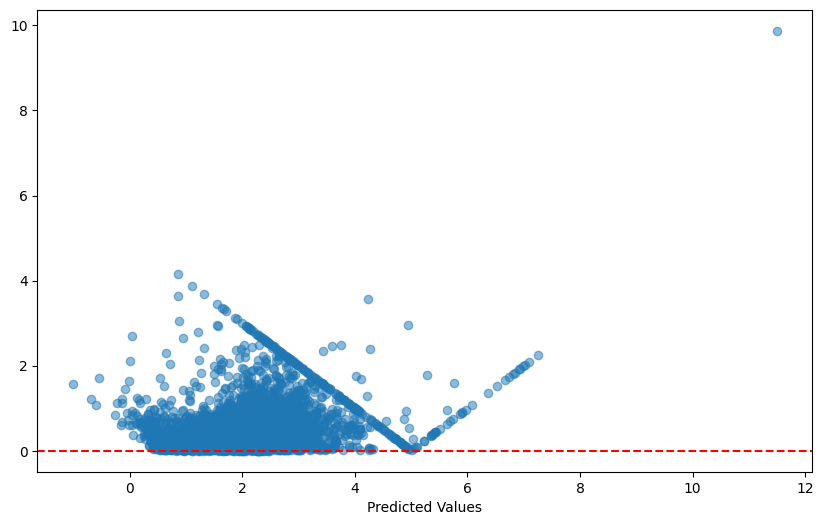

In [17]:
delta = y_test - y_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, abs(delta), alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')  
plt.show()

In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)
print(f'Регрессия LASSO - средняя квадратичная ошибка: {mse_lasso}')
print(f'Регрессия LASSO - R-квадрат: {r2_lasso}')

Регрессия LASSO - средняя квадратичная ошибка: 0.6796290284328821
Регрессия LASSO - R-квадрат: 0.4813611325029077


In [21]:
ridge = Ridge(alpha=0.1)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)
print(f'Ridge Regression - Mean Squared Error: {mse_ridge}')
print(f'Ridge Regression - R-квадрат: {r2_ridge}')

Ridge Regression - Mean Squared Error: 0.555887913867418
Ridge Regression - R-квадрат: 0.5757905180002314


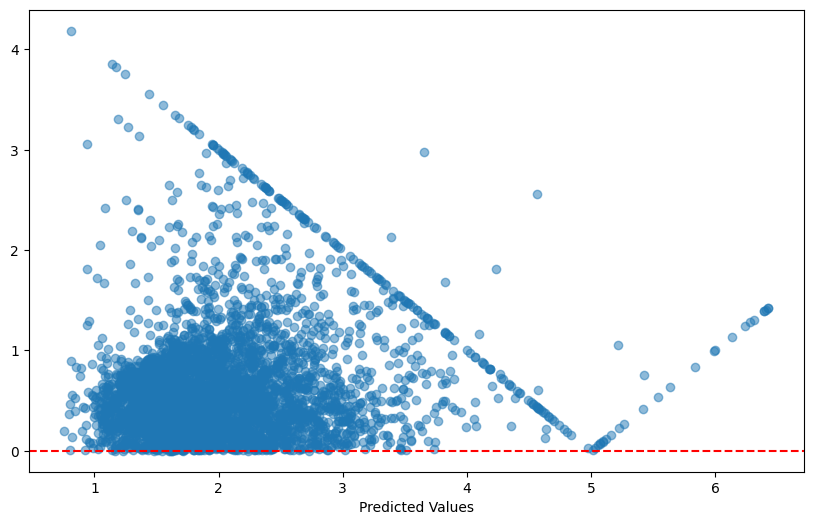

In [22]:
delta_lasso = y_test - y_pred_lasso
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_lasso, abs(delta_lasso), alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')  
plt.show()

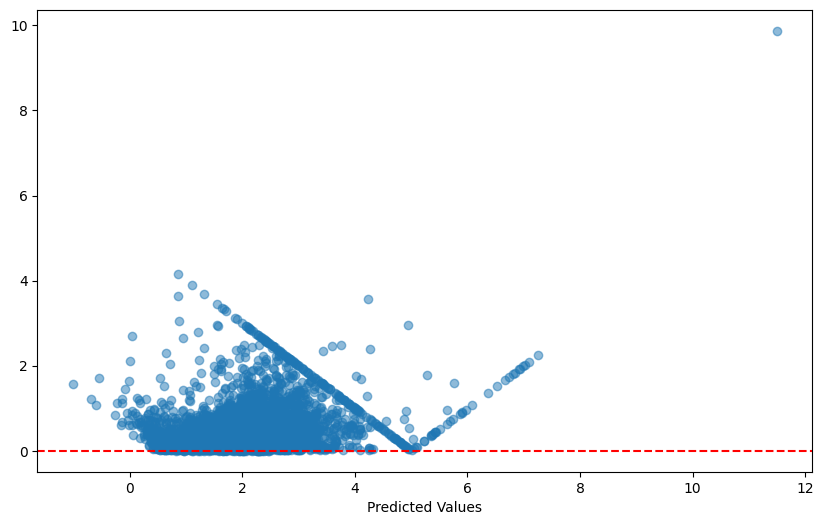

In [23]:
delta_ridge = y_test - y_pred_ridge
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_ridge, abs(delta_ridge), alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')  
plt.show()

In [25]:
model_tree = DecisionTreeRegressor(random_state=42)
model_tree.fit(X_train, y_train)
y_pred_tree = model_tree.predict(X_test)
mse_tree = mean_squared_error(y_test, y_pred_tree) 
r2_tree = r2_score(y_test, y_pred_tree)
print(f'Decision Tree - Mean Squared Error: {mse_tree}')
print(f'Decision Tree - R²: {r2_tree}')

Decision Tree - Mean Squared Error: 0.494255717630063
Decision Tree - R²: 0.622823312540521


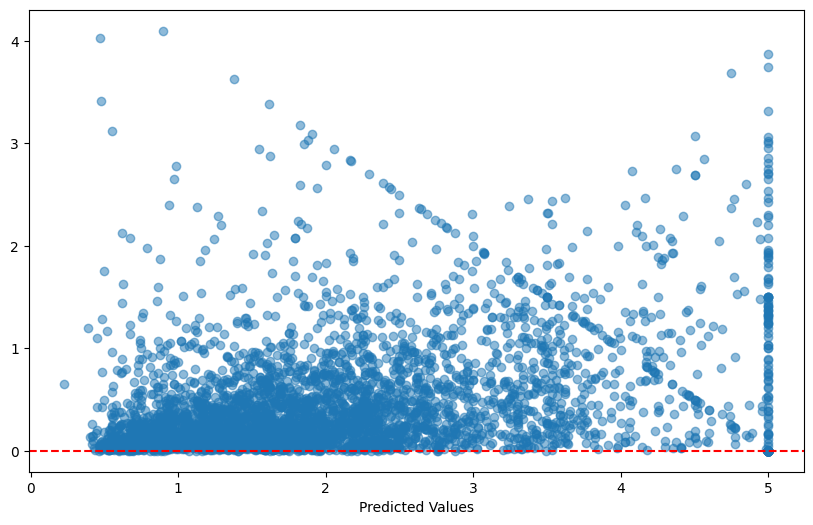

In [26]:
delta_tree = y_test - y_pred_tree
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_tree, abs(delta_tree), alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')  
plt.show()

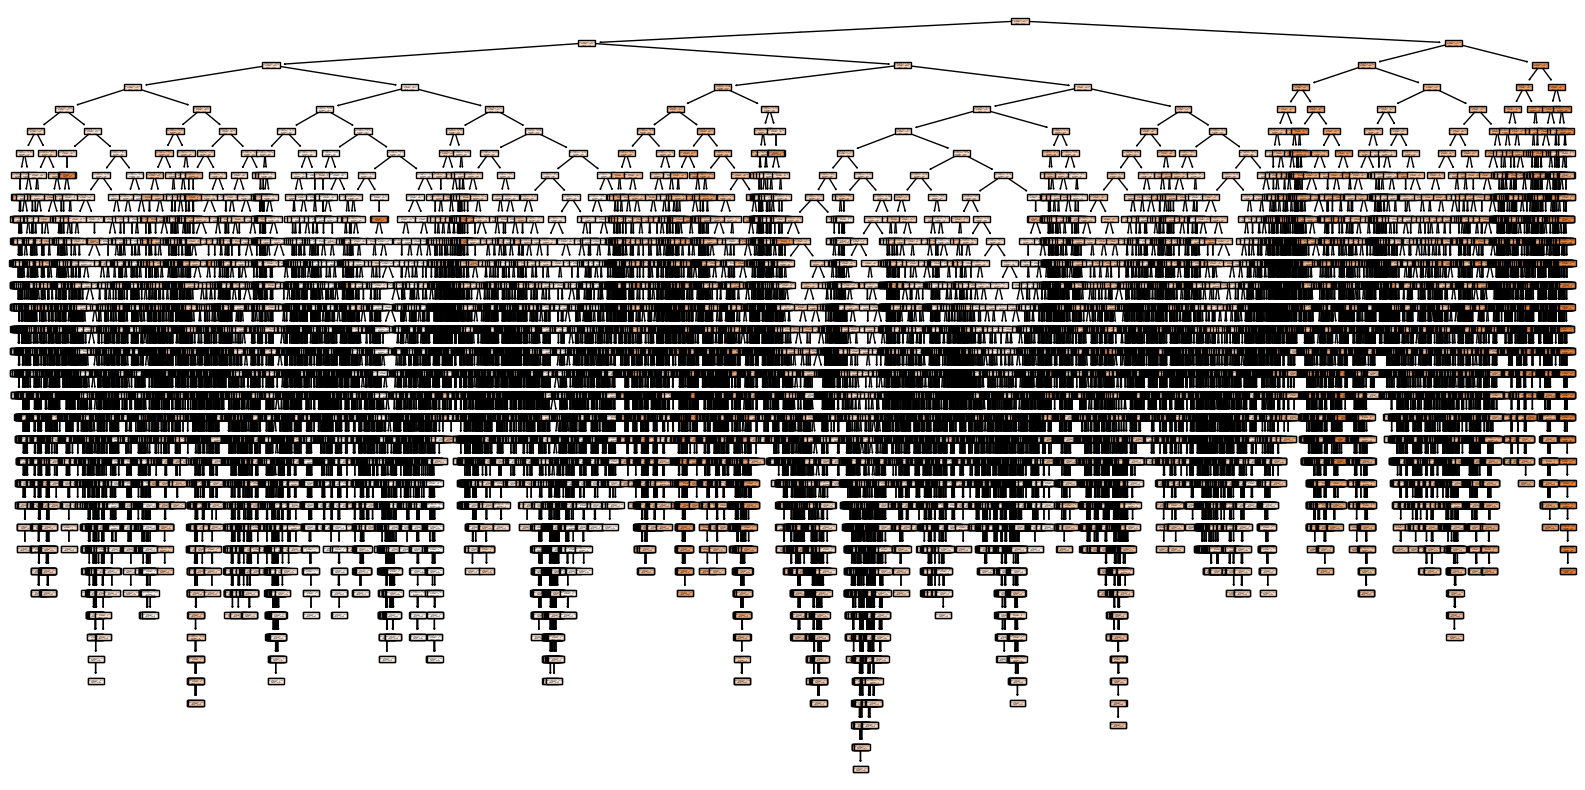

In [28]:
plt.figure(figsize=(20, 10))
plot_tree(model_tree, feature_names=california_housing.feature_names, filled=True)
plt.show()

### <b><font color='lightcoral'>Задача 2</font></b>
Реализуйте логистическую регрессию для классификации злокачественной или доброкачественной опухоли на наборе данных Breast Cancer. Оцените модель с помощью показателей accuracy, precision, recall и F1-score.

In [32]:
#Оцените модель с помощью показателей accuracy, precision, recall и F1-score.
# Вычислить точность
from sklearn.metrics import classification_report


accuracy_bc = accuracy_score(y_test_bc, y_pred_bc)
print('Accuracy:', accuracy_bc)
precision_bc = precision_score(y_test_bc, y_pred_bc)
print('precision', precision_bc)
recall_bc = recall_score(y_test_bc, y_pred_bc)
print('recall', recall_bc)
f1_bc = f1_score(y_test_bc, y_pred_bc)
print('F1-score', f1_bc)
# Отчет о классификации
print('Отчет о классификации:')
print(classification_report(y_test_bc, y_pred_bc))
# Accuracy - меткость
# precision  - точность
# recall - полнота

Accuracy: 0.956140350877193
precision 0.9459459459459459
recall 0.9859154929577465
F1-score 0.9655172413793104
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



### <b><font color='lightcoral'>Задача 3</font></b>
Реализуйте классификатор на основе дерева решений для предсказания качества вина, используя набор данных Wine. Оцените модель с помощью перекрестной валидации и постройте дерево решений.

In [35]:
wine = load_wine(as_frame=True)
display(wine.frame)
X_wine = wine.data
y_wine = wine.target
X_train_wine, X_test_wine, y_train_wine, y_test_wine = train_test_split(X_wine, y_wine, test_size=0.2, random_state=42)
model_wine = DecisionTreeClassifier(random_state=42)
model_wine.fit(X_train_wine, y_train_wine)
y_pred_wine = model_wine.predict(X_test_wine)
accuracy_wine = accuracy_score(y_test_wine, y_pred_wine)
print('Accuracy Wine:', accuracy_wine)
print('Отчет о классификации Wine:')
print(classification_report(y_test_wine, y_pred_wine))

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


Accuracy Wine: 0.9444444444444444
Отчет о классификации Wine:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        14
           1       0.93      1.00      0.97        14
           2       1.00      0.88      0.93         8

    accuracy                           0.94        36
   macro avg       0.95      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36



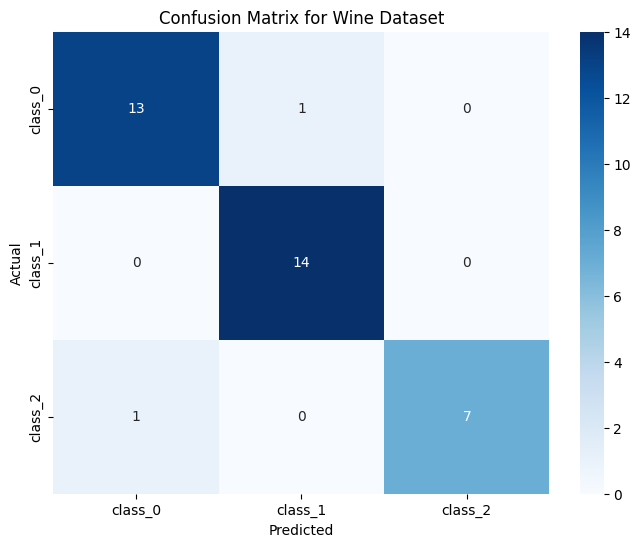

In [36]:
matrix_wine = confusion_matrix(y_test_wine, y_pred_wine)
plt.figure(figsize=(8, 6)) 
sns.heatmap(matrix_wine, annot=True, fmt='d', cmap='Blues', xticklabels=wine.target_names, yticklabels=wine.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Wine Dataset')
plt.show()


### <b><font color='lightcoral'>Задача 4</font></b>
Реализуйте модель K-Nearest Neighbors (KNN) для классификации рукописных цифр с помощью набора данных Digits. Оцените модель по точности и постройте матрицу ошибок.

### <b><font color='lightcoral'>Задача 5</font></b>
Постройте кривые обучения для диагностики переобучения и недообучения, используя набор данных Iris и модель Decision Tree. Постройте кривые обучения для ошибок обучения и проверки.

### <b><font color='lightcoral'>Задача 6</font></b>
Реализуйте регрессию LASSO и ридж-регрессию, используя набор данных Iris. Сравните эффективность обеих моделей, используя среднюю квадратичную ошибку (MSE) и R-квадрат (R²). Постройте графики коэффициентов обеих моделей.